In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

df = pd.read_csv('silver_with_indicators.csv')
for c in df.columns:
    if df[c].dtype in [float, int, np.float64]:
            if 5 < df[c].median() < 80 and 'rsi' not in c.lower() and 'ma' not in c.lower():
                        price_col = c; break
print(f"Using: {price_col}")

data = df[[price_col]].dropna().values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_seq(data, seq=60):
    X,y=[],[]
    for i in range(seq, len(data)):
        X.append(data[i-seq:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X,y = create_seq(data_scaled, 60)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train {X_train.shape} Test {X_test.shape} - Ready!")

Using: Open
Train (5378, 60, 1) Test (1345, 60, 1) - Ready!


In [5]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)
print("Training DONE!")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 0.0041 - val_loss: 5.4157e-04
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 0.0013 - val_loss: 4.9187e-04
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 0.0011 - val_loss: 7.3732e-04
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 9.3998e-04 - val_loss: 4.1376e-04
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 7.7459e-04 - val_loss: 7.5917e-04
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 8.4094e-04 - val_loss: 6.0290e-04
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 6.4499e-04 - val_loss: 3.6350e-04
Epoch 9/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 6.5291e-04 - val_loss: 3.5917e-04
Epoch 10/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - loss: 7.0586e-04 - val_loss: 3.4081e-04
Epoch 11/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 6.2966e

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step


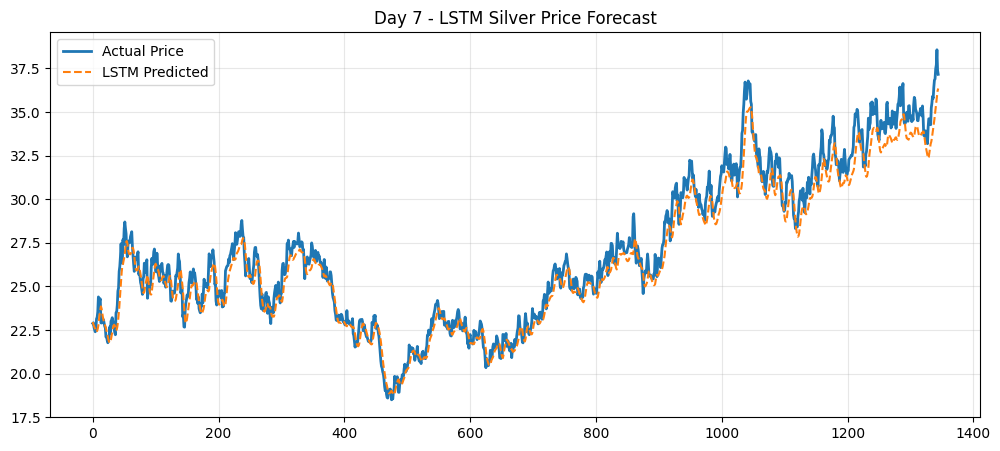

✅ RMSE: 0.92 | MAE: 0.73
Files Saved!


In [6]:
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(12,5))
plt.plot(actual, label='Actual Price', linewidth=2)
plt.plot(pred, label='LSTM Predicted', linestyle='--')
plt.legend(); plt.title('Day 7 - LSTM Silver Price Forecast'); plt.grid(alpha=0.3)
plt.savefig('Day_7_LSTM_Forecast.png', dpi=300)
plt.show()

rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)
print(f"✅ RMSE: {rmse:.2f} | MAE: {mae:.2f}")

pd.DataFrame({'Actual': actual.flatten(), 'LSTM_Pred': pred.flatten()}).to_csv('Day_7_LSTM_Predictions.csv', index=False)
with open('Day_7_LSTM_Metrics.txt','w') as f:
    f.write(f"LSTM Metrics\nRMSE: {rmse}\nMAE: {mae}\n")

    print("Files Saved!")